# COVID-19 Predictive Model
## Jess Denton
### Module: DC3DMN

## Table of Contents
1. Academic Integrity Statement
2. Introduction
3. Ingesting and Preparing the Data
4. Building the Model
5. Testing and Iterations
6. Conclusion
7. References
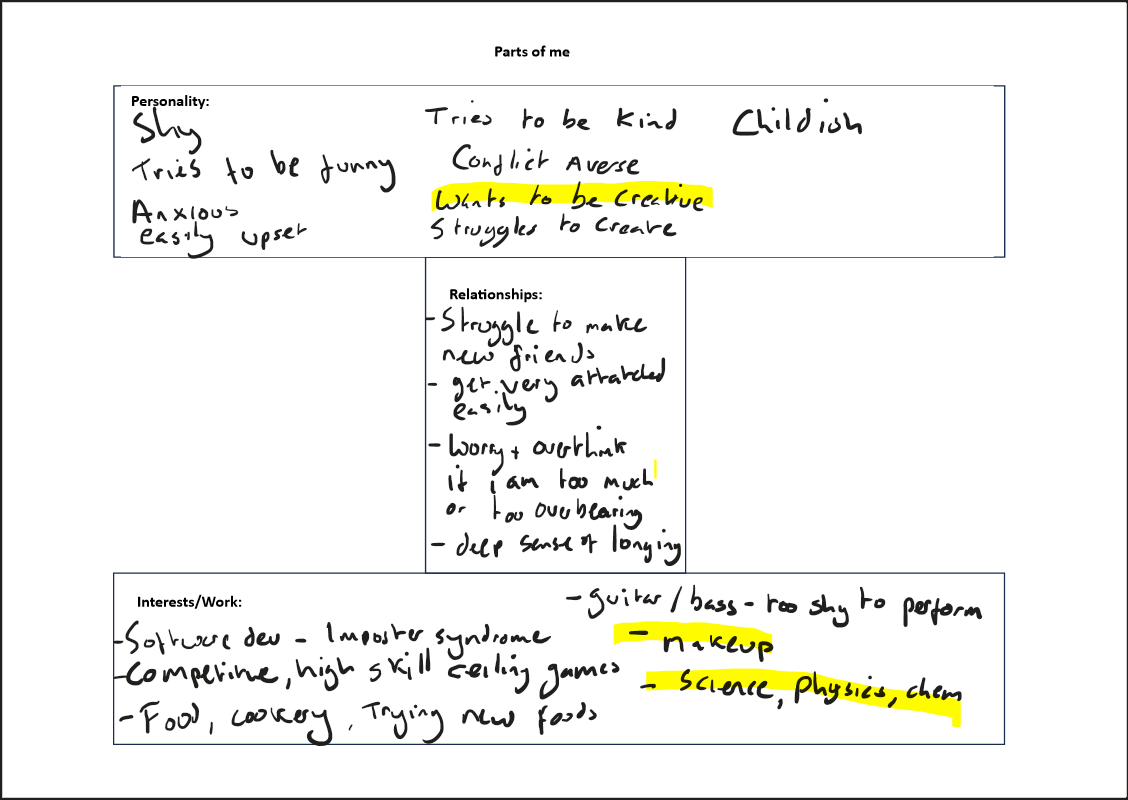

### Academic Integrity Statement
 I declare that I have personally prepared this assignment. The work is my own, carried out personally by me unless otherwise stated and has not been generated using Artificial Intelligence tools unless specified as a clearly stated approved component of the assessment brief. All sources of information, including quotations, are acknowledged by means of the appropriate citations and references. I declare that this work has not gained credit previously for another module at this or another University.

I understand that plagiarism, collusion, copying another student and commissioning (which for the avoidance of doubt includes the use of essay mills and other paid for assessment writing services, as well as unattributed use of work generated by Artificial Intelligence tools) are regarded as offences against the University’s Assessment Regulations and may result in formal disciplinary proceedings.

### Introduction
In this notebook I will be analysing a provided data extract of COVID-19 test results to train a machine learning model and provide predictions over a similar unseen dataset. To do so I will be applying data mining techniques in order to extract valuable features from the data set and train my own machine learning algorithm on them. Data mining is defined as *'the use of machine learning and statistical analysis to uncover patterns and other valuable information from large data sets' (Holdsworth, J. 2024)*. The sample data extract has 3999 rows across 106 columns that include potentially relevant predictor data. There is also 1 column of 3999 COVID-19 test results which are known as the classifiers for this data set. As the data set sits at the moment the gap between data and information is sizeable. It is difficult for a human to parse large data sets and extract meaningful conclusions, the data mining process aims to reduce that gap, and in this case provide an algorithm that could be used to predict cases of COVID-19 among a population. The body of the report will intersperse runnable lines of code that I have used to create the machine learning algorithm alongside explanations and theory that support my choices.

## Ingesting and Preparing the Data

### Raw Data & Imports
The first part of carry out data mining is to understand the dataset that will be used. In this case we are trying to make a model that carries out a form of binary classification to predict either a positive or negative COVID-19 assay. Classification is a type of data mining that aims to isolate features that have high influence over the outcome and use them to predict outcomes from a different set of feature values. *Geeks for Geeks* define classification as; *'Classification in data mining is a supervised learning approach used to assign data points into predefined classes based on their features. By analysing labelled historical data, classification algorithms learn patterns and relationships that enable them to categorize new, unseen data accurately.'(GeeksForGeeks, 2018)*. Features are component columns in the data which in this case represent a test, symptom or observation for a specific record. For example in the raw csv the column feat_hemoglobin contains a numeric value denoting the result of a test which calculates the level of hemoglobin present in a given sample. There are 106 different feature columns present in the data extract as well as one classification column and one ID column. The first step to take is to ingest this data into the notebook using the python pandas library. Before we can use pandas it needs to be imported, which is true for all libraries (or parts of libraries) that are used throughout the report. The first code block below will run all necessary imports.


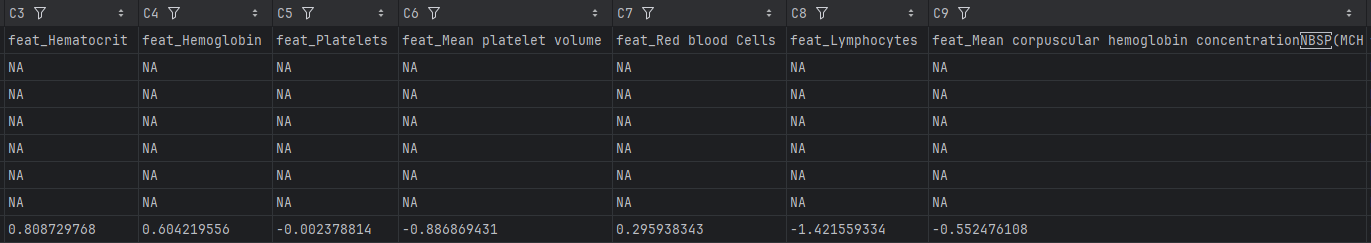

In [43]:
#Run imports for libraries to be used
import pandas as pd
import pandasql as ps
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
pd.options.display.max_rows = 100
pd.options.display.max_columns = 110

### Ingesting the raw CSV
The data extract provided is a CSV file with ANSI encoding. As stated, we are going to be using pandas to load the data in. Pandas creates data frame objects which hold the ingested data in a 2-dimensional mutable array. The 'read_csv' method from Pandas is invoked to load the data into a dataframe. We have chosen to use a separate JSON schema to specify data types for each column in the CSV to make the data simpler to work with. Usually this method will attempt to infer the data type (also referred to as dtypes) for each column, but this can lead to unexpected dtypes in columns which may result in having to cast an entire column as a different dtype later. Using a schema removes this ambiguity. We also pass in additional values to cast to true or false for boolean columns, accounting for the most common ones in the dataset.

In [44]:
#load the schema
with open('ingest_schema.json') as f:
    schema = json.load(f)

#Use the schema and other params to ingest the csv.
df_all = pd.read_csv(
    filepath_or_buffer ="CW_data.csv",
    encoding='ANSI',
    dtype = schema,
    true_values = ["positive", "detected"],
    false_values = ["negative", "not_detected"],
    on_bad_lines = "warn"
    )
print(df_all.dtypes)
#Check the head of the dataframe
df_all.head(10)


Patient ID                                  object
Patient age quantile                         Int64
feat_Hematocrit                            Float64
feat_Hemoglobin                            Float64
feat_Platelets                             Float64
                                            ...   
feat_pO2 (arterial blood gas analysis)     Float64
feat_Arteiral Fio2                         Float64
feat_Phosphor                              Float64
feat_ctO2 (arterial blood gas analysis)    Float64
SARS-Cov-2 exam result                     boolean
Length: 108, dtype: object


,Patient ID,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Serum Glucose,feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Mycoplasma pneumoniae,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Urea,feat_Proteina C reativa mg/dL,feat_Creatinine,feat_Potassium,feat_Sodium,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",feat_Alanine transaminase,feat_Aspartate transaminase,feat_Gamma-glutamyltransferase,feat_Total Bilirubin,feat_Direct Bilirubin,feat_Indirect Bilirubin,feat_Alkaline phosphatase,feat_Ionized calcium,feat_Strepto A,feat_Magnesium,feat_pCO2 (venous blood gas analysis),feat_Hb saturation (venous blood gas analysis),feat_Base excess (venous blood gas analysis),feat_pO2 (venous blood gas analysis),feat_Fio2 (venous blood gas analysis),feat_Total CO2 (venous blood gas analysis),feat_pH (venous blood gas analysis),feat_HCO3 (venous blood gas analysis),feat_Rods #,feat_Segmented,feat_Promyelocytes,feat_Metamyelocytes,feat_Myelocytes,feat_Myeloblasts,feat_Urine - Esterase,feat_Urine - Aspect,feat_Urine - pH,feat_Urine - Hemoglobin,feat_Urine - Bile pigments,feat_Urine - Ketone Bodies,feat_Urine - Nitrite,feat_Urine - Density,feat_Urine - Urobilinogen,feat_Urine - Protein,feat_Urine - Sugar,feat_Urine - Leukocytes,feat_Urine - Crystals,feat_Urine - Red blood cells,feat_Urine - Hyaline cylinders,feat_Urine - Granular cylinders,feat_Urine - Yeasts,feat_Urine - Color,feat_Partial thromboplastin time (PTT),feat_Relationship (Patient/Normal),feat_International normalized ratio (INR),feat_Lactic Dehydrogenase,"feat_Prothrombin time (PT), Activity",feat_Vitamin B12,feat_Creatine phosphokinase (CPK),feat_Ferritin,feat_Arterial Lactic Acid,feat_Lipase dosage,feat_D-Dimer,feat_Albumin,feat_Hb saturation (arterial blood gases),feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),SARS-Cov-2 exam result
0,715f6bdee94fdd7,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,NaN,False,False,False,False,False,False,False,True,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
1,4495129155a2cc9,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
2,af17911deea7b00,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>

### Preprocessing
In this section we wil carry out preprocessing tasks to make the data ready for further processing. Within the df_all 2 things immediately stand out, there is a superfluous column for patient IDs and there are lots of NA or NaN values. Firstly we can remove the entire ID column as it is not needed for the processing we will be carrying out. We do this now to lessen processing time for the more complex operations to come, as removing this column eliminates around 4000 cells in the dataframe.

In [45]:
#Remove the patient ID column and check the rest of the data is as expected
df_all.drop('Patient ID', axis = 1, inplace = True)
df_all.head(10)

,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Serum Glucose,feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Mycoplasma pneumoniae,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Urea,feat_Proteina C reativa mg/dL,feat_Creatinine,feat_Potassium,feat_Sodium,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",feat_Alanine transaminase,feat_Aspartate transaminase,feat_Gamma-glutamyltransferase,feat_Total Bilirubin,feat_Direct Bilirubin,feat_Indirect Bilirubin,feat_Alkaline phosphatase,feat_Ionized calcium,feat_Strepto A,feat_Magnesium,feat_pCO2 (venous blood gas analysis),feat_Hb saturation (venous blood gas analysis),feat_Base excess (venous blood gas analysis),feat_pO2 (venous blood gas analysis),feat_Fio2 (venous blood gas analysis),feat_Total CO2 (venous blood gas analysis),feat_pH (venous blood gas analysis),feat_HCO3 (venous blood gas analysis),feat_Rods #,feat_Segmented,feat_Promyelocytes,feat_Metamyelocytes,feat_Myelocytes,feat_Myeloblasts,feat_Urine - Esterase,feat_Urine - Aspect,feat_Urine - pH,feat_Urine - Hemoglobin,feat_Urine - Bile pigments,feat_Urine - Ketone Bodies,feat_Urine - Nitrite,feat_Urine - Density,feat_Urine - Urobilinogen,feat_Urine - Protein,feat_Urine - Sugar,feat_Urine - Leukocytes,feat_Urine - Crystals,feat_Urine - Red blood cells,feat_Urine - Hyaline cylinders,feat_Urine - Granular cylinders,feat_Urine - Yeasts,feat_Urine - Color,feat_Partial thromboplastin time (PTT),feat_Relationship (Patient/Normal),feat_International normalized ratio (INR),feat_Lactic Dehydrogenase,"feat_Prothrombin time (PT), Activity",feat_Vitamin B12,feat_Creatine phosphokinase (CPK),feat_Ferritin,feat_Arterial Lactic Acid,feat_Lipase dosage,feat_D-Dimer,feat_Albumin,feat_Hb saturation (arterial blood gases),feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),SARS-Cov-2 exam result
0,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,NaN,False,False,False,False,False,False,False,True,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
1,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
2,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>

Next we will look at the NaN & NA values. While most of these should be dealt with later so that we do not reduce the resolution of the data set too far, some columns have either got only NaN values or values that are all identical. Columns that are all NaN are useless for data mining as they cannot be used as a predictor for the model. The same goes for columns where the value is all equal but not NaN, as these columns have no variance they can be discounted as being influential over the COVID-19 test result.

In [46]:
#Find all columns with only a single unique value in the column
df_single_values =  df_all.loc[:, df_all.nunique(dropna = False) == 1]
df_single_values.head(5)

,feat_Mycoplasma pneumoniae,feat_Fio2 (venous blood gas analysis),feat_Urine - Nitrite,feat_Urine - Sugar,feat_Partial thromboplastin time (PTT),"feat_Prothrombin time (PT), Activity",feat_D-Dimer
0,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
1,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
2,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
3,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
4,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN


We can now see all the columns that have only one unique value in them and in this case they are all NaN or NA values. We can safely drop these columns from df_all as they have no further use.

In [47]:
#Drop all columns with 1 or less unique values from df_all
df_all = df_all.drop(labels = df_single_values.columns, axis = 1)

Now that we have dealt with all columns that are NaN only, we can do the same for rows that are NaN only. We need to ignore the patient quantile and the test result columns for this, as they are populated for all rows.

In [48]:
#Ignore the patient quantile and exam result
ignored_cols = ["Patient age quantile", "SARS-Cov-2 exam result"]
all_feats_cols = df_all.columns.difference(ignored_cols)

df_all = df_all.dropna(how = "all", subset = all_feats_cols)
print(f'The current shape of df_all is: {df_all.shape}')

The current shape of df_all is: (1496, 100)


Next we can look at the number of missing values per column. Columns that have a high number of missing values are likely to be poor predictors. To do this we can use a plot that will show us the number of missing data points per column. This visual aid will help set a threshold to drop columns that have too many missing values at.

Text(0, 0.5, 'Number of NaNs')

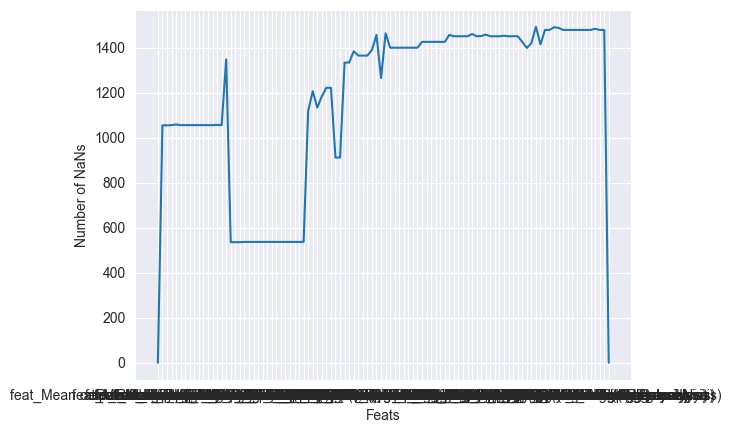

In [49]:
missing_per_column = df_all.isnull().sum(axis=0)
plt.plot(missing_per_column)
plt.xlabel('Feats')
plt.ylabel('Number of NaNs')

We can see that the data set has a large number of columns with over 1200 missing values. Given the large number of columns, it will be easier to parse by putting this into a readable numerical format.

In [50]:
#Find out the average amount of missing values, identify columns that have a disproportionate amount of missing values.
avg_missing = missing_per_column.mean()
num_columns_over_avg = (missing_per_column > avg_missing).sum()
columns_over_avg = missing_per_column[missing_per_column > avg_missing]
print(f'The average number of missing values is {avg_missing}. There are {num_columns_over_avg} columns with missing values over the average. They are: \n{columns_over_avg}')

The average number of missing values is 1173.78. There are 63 columns with missing values over the average. They are: 
feat_Serum Glucose                                1348
feat_Urea                                         1207
feat_Creatinine                                   1184
feat_Potassium                                    1222
feat_Sodium                                       1222
feat_Alanine transaminase                         1334
feat_Aspartate transaminase                       1334
feat_Gamma-glutamyltransferase                    1384
feat_Total Bilirubin                              1365
feat_Direct Bilirubin                             1365
feat_Indirect Bilirubin                           1365
feat_Alkaline phosphatase                         1390
feat_Ionized calcium                              1457
feat_Strepto A                                    1265
feat_Magnesium                                    1464
feat_pCO2 (venous blood gas analysis)             1400
f

There are a vast amount of missing values in the dataset, with 62 columns having 80% or more of their data missing. Using this information, we can set a threshold value for maximum number of NaN values in a column, and eliminate any that go over that threshold. For this case I will eliminate any columns that have more than 1200 NaN values. This will eliminate a vast number of columns, but the good data they contained would likely have been drowned out by the amount of noise that the missing values introduced. Carrying out a form of mean imputing could let us keep more columns, however over this many missing values it would also have skewed the results too far to remain reliable.

In [51]:
#Drop all columns missing over 1200 data points.
threshold = missing_per_column < 1200
df_all = df_all.loc[:,threshold]
print(f'The current shape of df_all is: {df_all.shape}')

The current shape of df_all is: (1496, 38)


### Non Numeric data types

Now that we have eliminated columns that are of low statistical significance we can check and see if there are any non-numeric data types left in the dataset. These datatypes pose a problem if left as they are, as normalisation and other statistical evaluations can only be run where all datatypes are numerical. We cannot remove these columns just because they are non-numeric as they may contain significant statistical value to correctly predicting the outcome of a COVID-19 test. So we need to convert these values into something more parsable for our model.

In [52]:
print(df_all.dtypes)
df_all.head(6)

Patient age quantile                                       Int64
feat_Hematocrit                                          Float64
feat_Hemoglobin                                          Float64
feat_Platelets                                           Float64
feat_Mean platelet volume                                Float64
feat_Red blood Cells                                     Float64
feat_Lymphocytes                                         Float64
feat_Mean corpuscular hemoglobin concentration (MCHC)    float64
feat_Leukocytes                                          Float64
feat_Basophils                                           Float64
feat_Mean corpuscular hemoglobin (MCH)                   Float64
feat_Eosinophils                                         Float64
feat_Mean corpuscular volume (MCV)                       Float64
feat_Monocytes                                           Float64
feat_Red blood cell distribution width (RDW)             Float64
feat_Respiratory Syncytia

,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Proteina C reativa mg/dL,feat_Creatinine,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",SARS-Cov-2 exam result
0,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,False
6,4,0.80873,0.60422,-0.002379,-0.886869,0.295938,-1.421559,-0.552476,2.443296,-0.529226,0.439533,-0.793368,0.807138,0.488863,-0.271247,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.462405,0.07465,<NA>,False,False,False
7,13,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,False
9,6,1.335167,1.544059,-0.002379,-0.101517,1.230347,-0.099557,1.040773,-0.768046,1.303529,0.334989,-0.498393,-0.114222,0.278757,0.259492,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.10206,-0.529401,<NA>,<NA>,<NA>,False
10,19,0.556955,0.478908,-0.969638,1.132609,0.119635,-0.756294,-0.154166,-0.656734,-0.529226,0.596348,-0.835508,0.727019,1.171706,-0.713529,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.618335,0.801897,0.125653,<NA>,<NA>,True
14,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,<NA>,False,False,False


We can see in the dtypes list that there are only float64, int64 and boolean values remaining. We can explicitly convert the booleans to 0 for false and 1 for true so that we can carry out further operations on them with the rest of the numerical data. The boolean type accounts for NaN values, and python is able to automatically recognise True == 1 and False == 0, so there is no additional processing required.

In [56]:
#find all the boolean dtype columns and convert them to ints
boolean_cols = df_all.select_dtypes(include = "boolean").columns
df_all[boolean_cols] = df_all[boolean_cols].astype("Float64")
#Compare the dytpes and df_all head to the precast versions above and check for issues
print(df_all.dtypes)
print(df_all.shape)
df_all.head(10)

Patient age quantile                                       Int64
feat_Hematocrit                                          Float64
feat_Hemoglobin                                          Float64
feat_Platelets                                           Float64
feat_Mean platelet volume                                Float64
feat_Red blood Cells                                     Float64
feat_Lymphocytes                                         Float64
feat_Mean corpuscular hemoglobin concentration (MCHC)    float64
feat_Leukocytes                                          Float64
feat_Basophils                                           Float64
feat_Mean corpuscular hemoglobin (MCH)                   Float64
feat_Eosinophils                                         Float64
feat_Mean corpuscular volume (MCV)                       Float64
feat_Monocytes                                           Float64
feat_Red blood cell distribution width (RDW)             Float64
feat_Respiratory Syncytia

,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Proteina C reativa mg/dL,feat_Creatinine,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",SARS-Cov-2 exam result
0,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
6,4,0.80873,0.60422,-0.002379,-0.886869,0.295938,-1.421559,-0.552476,2.443296,-0.529226,0.439533,-0.793368,0.807138,0.488863,-0.271247,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.462405,0.07465,<NA>,0.0,0.0,0.0
7,13,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
9,6,1.335167,1.544059,-0.002379,-0.101517,1.230347,-0.099557,1.040773,-0.768046,1.303529,0.334989,-0.498393,-0.114222,0.278757,0.259492,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.10206,-0.529401,<NA>,<NA>,<NA>,0.0
10,19,0.556955,0.478908,-0.969638,1.132609,0.119635,-0.756294,-0.154166,-0.656734,-0.529226,0.596348,-0.835508,0.727019,1.171706,-0.713529,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.618335,0.801897,0.125653,<NA>,<NA>,1.0
14,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>,0.0,0.0,0.0
16,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0
17,11,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0
18,19,0.488289,0.729532,0.148363,0.010677,0.542763,-1.319211,1.040773,0.439686,-0.834685,0.230447,-0.835508,-0.254428,-1.979879,0.082579,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2.126187,<NA>,<NA>,<NA>,<NA>,0.0
21,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0


With that step completed, the preprocessing for this dataset is complete, and we can move on to processing the data for use in building the machine learning algorithm.

## Building the Model

In order to build an accurate model we will need to carry out the following:
* Deal with outlier values
* Impute or otherwise remove NaN values

classifiers shape is (1496,)
scaled predictor shape is: (1496, 38)


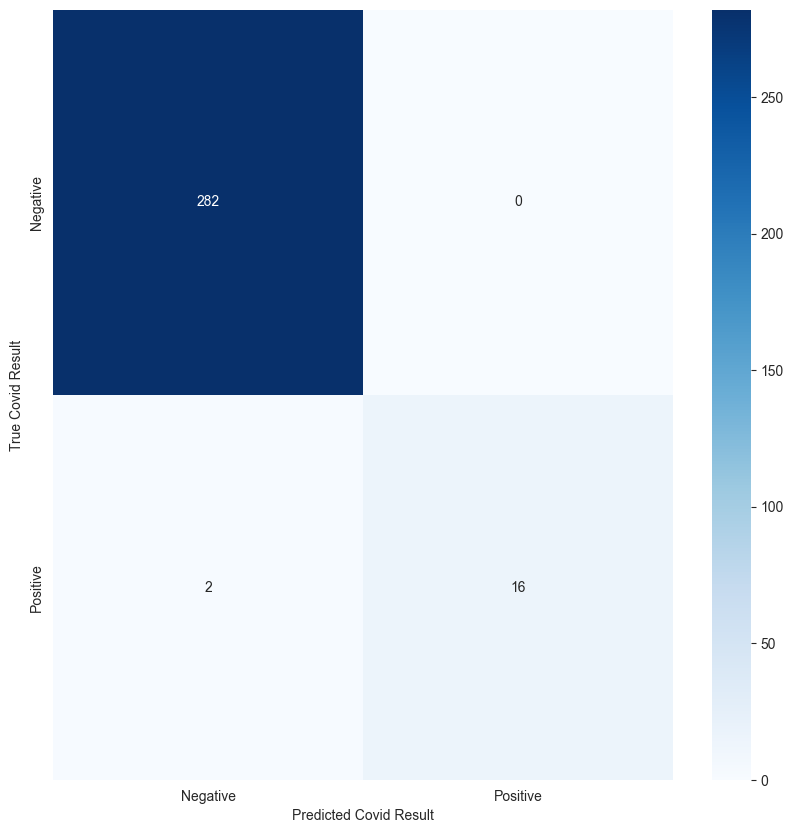

In [54]:
#Grab classifiers
df_classifiers = df_all['SARS-Cov-2 exam result']
print(f'classifiers shape is {df_classifiers.shape}')
#deal with NANs in the numerical - this will need to be done properly with outlier handling, but for now, fuck it. MEAN TIME BABY
df_no_nans = df_all.fillna(df_all.mean())

#Scale this shit down
scaler = StandardScaler()
df_scaled_predictors = scaler.fit_transform(df_no_nans)
print(f'scaled predictor shape is: {df_scaled_predictors.shape}')

#create a pca and fit that bitch up
pca = PCA(n_components = 10)
predictor_pca = pca.fit_transform(df_scaled_predictors)

#split em
predictor_train, predictor_test, classifier_train, classifier_test = train_test_split(predictor_pca, df_classifiers, test_size = 0.2)

#predict em
model = LogisticRegression()
model.fit(predictor_train, classifier_train)
classifier_pred = model.predict(predictor_test)

#visualise em
cm = confusion_matrix(classifier_test, classifier_pred)
plt.figure(figsize = (10,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Covid Result')
plt.ylabel('True Covid Result')
plt.show()

In [55]:
score = f1_score(classifier_test, classifier_pred, average='macro')
print(f" F1 score is {score}")

 F1 score is 0.9688214508418208


## References

* Holdsworth, J. (2024). What is data mining? [online] Ibm.com. Available at: https://www.ibm.com/think/topics/data-mining
* GeeksforGeeks (2018). Basic Concept of Classification (Data Mining). [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/classification-in-data-mining/
